# Lab05 : Thực hành cài đặt thuật toán thỏa mãn ràng buộc
## Bài toán N-Queens (N quân hậu)

**Mô tả:**  
Đặt N quân hậu lên bàn cờ NxN sao cho không có cặp quân hậu nào tấn công nhau
(Bài toán mở rộng của 8-Queens)

**Mục tiêu notebook:**
- Hiểu bài toán N-Queens
- Cài đặt Backtracking
- Cài đặt Heuristic Min-Conflicts
- So sánh hiệu quả giữa hai phương pháp


### Xác định bài toán:  

**Trạng thái:** Bao gồm tập biến: $V = \{v_1,v_2,v_3,...,v_N\}$, trong đó $v_i$ biểu diễn cột của quân hậu tại dòng $i$

**Miền giá trị:** với mỗi $v_i$ có $D(v_i) = \{0,1,2,...,N-1\}$  

**Các ràng buộc chính:** Các quân hậu không tấn công lẫn nhau:
$\forall i\neq j$, (với $i$, $j$ là 2 dòng khác nhau)
+ Ràng buộc hàng: Không có vì mỗi hậu nằm trên một hàng khác nhau
+ Ràng buộc cột: $v_i \neq v_j$
+ Ràng buộc đường chéo chính/phụ: $|v_i-i| \neq |v_j - j|$

### Biểu diễn trạng thái: 

 Biểu diễn trạng thái bàn cờ dưới dạng vị trí hậu của từng dòng

In [1]:
## Biểu diễn trạng thái bàn cờ dưới dạng vị trí hậu của từng dòng
'''
pos = []
pos[i] = k
Tương ứng với hậu đặt ở dòng i cột k
Cài đặt theo hướng đặt hậu theo từng hàng
## Ta có các ô ko thể đặt nếu đã đặt dòng trước đó một hậu ở (i,j) với k là hằng số ta có:
## Chéo chính: (i+k, j+k), chéo phụ: (i+k, j-k), cột dọc: (i+k, j)
## Tại mỗi ô (x,y) so với (i,j) thì nếu:
## Trùng đường chéo chính: có x = y + k và (x,y) = (i+k,j+k) 
#                                   => x-i = k và y-j = k 
#                                   => x-i = y-j = k
#                                   =>|x-i| = |y-j| = k

## Trùng đường chéo phụ : x = k-y và (x,y) = (i+k,j-k) 
#                                   => x-i = k và y-j = -k <=> |y-j| = k
#                                   => x-i = |y-j| = k
#                                   => |x-i| = |y-j| = k
 
## Suy ra tổng quát: Trùng cả hai chéo: |x-i| = |y-j| = k
## Trùng dọc: chỉ số cột bằng nhau
'''

'\npos = []\npos[i] = k\nTương ứng với hậu đặt ở dòng i cột k\nCài đặt theo hướng đặt hậu theo từng hàng\n## Ta có các ô ko thể đặt nếu đã đặt dòng trước đó một hậu ở (i,j) với k là hằng số ta có:\n## Chéo chính: (i+k, j+k), chéo phụ: (i+k, j-k), cột dọc: (i+k, j)\n## Tại mỗi ô (x,y) so với (i,j) thì nếu:\n## Trùng đường chéo chính: có x = y + k và (x,y) = (i+k,j+k) \n#                                   => x-i = k và y-j = k \n#                                   => x-i = y-j = k\n#                                   =>|x-i| = |y-j| = k\n\n## Trùng đường chéo phụ : x = k-y và (x,y) = (i+k,j-k) \n#                                   => x-i = k và y-j = -k <=> |y-j| = k\n#                                   => x-i = |y-j| = k\n#                                   => |x-i| = |y-j| = k\n\n## Suy ra tổng quát: Trùng cả hai chéo: |x-i| = |y-j| = k\n## Trùng dọc: chỉ số cột bằng nhau\n'

### Cài đặt backtracking:

#### Giải thuật tổng quát:
```
BACKTRACK(row):
    if row == N:
        return SUCCESS   // đã đặt đủ N quân hậu
    for col = 0 to N-1:
        if isSafe(row, col):
            pos[row] = col
            if BACKTRACK(row + 1) == SUCCESS:
                return SUCCESS
            pos[row] = UNASSIGNED
    return FAILURE

N-QUEENS(N):
    khởi tạo pos[0..N-1] = UNASSIGNED
    BACKTRACK(0)
``` 

#### Cài đặt:

In [108]:
import numpy as np

def parseBoard(pos, verbose = True): ## Hàm in bàn cờ từ mảng pos
    N = len(pos)                                ## kích thước pos --> tạo mảng nxn
    board = np.full((N,N),".", dtype='<U3')     ## tạo mảng 2d fill hết là dấu .
    for r, c in enumerate(pos):
        board[r][c] = "Q"       
    if verbose:                ## đặt hậu
        for r in range(len(board)):                 ## in bàn cờ
            for c in range(len(board[r])):
                print(f'{board[r][c]}', end=" ")
            print()

In [109]:

def check_valid(row, col, pos):                 ## kiểm tra vùng tấn công
    for i in range(0, row):
        if pos[i] == col: return False          ## kiểm tra trùng cột
        if abs(row - i) == abs(col - pos[i]): return False
    return True

def backtracking(row, N, pos, counter):
    if row == N:
        counter[0] += 1                         ## Đếm số trạng thái đúng (kể cả đối xứng)
        print(f"Way {counter[0]}:")
        parseBoard(pos)                         ## in bàn cờ đúng
        print()
        return 1
    count = 0
    for col in range (0, N):
        if check_valid(row, col, pos):
            pos.append(col)                     ##
            count += backtracking(row+1, N, pos, counter) # đệ quy
            pos.pop()                           # backtracking trả về trạng thái cũ
    return count

def N_Queens(N):
    print(f'Bàn cờ {N}x{N}')
    pos = []                                    ## Tương ứng pos[i] = k (đặt hậu vị trí cột k dòng i)
    counter = [0]
    count = backtracking(0, N, pos, counter)
    print(f'có {count} cách đặt {N} quân hậu không tấn công nhau\n')
    parseBoard(pos)
    

In [110]:
N_Queens(4)
N_Queens(8)

Bàn cờ 4x4
Way 1:
. Q . . 
. . . Q 
Q . . . 
. . Q . 

Way 2:
. . Q . 
Q . . . 
. . . Q 
. Q . . 

có 2 cách đặt 4 quân hậu không tấn công nhau

Bàn cờ 8x8
Way 1:
Q . . . . . . . 
. . . . Q . . . 
. . . . . . . Q 
. . . . . Q . . 
. . Q . . . . . 
. . . . . . Q . 
. Q . . . . . . 
. . . Q . . . . 

Way 2:
Q . . . . . . . 
. . . . . Q . . 
. . . . . . . Q 
. . Q . . . . . 
. . . . . . Q . 
. . . Q . . . . 
. Q . . . . . . 
. . . . Q . . . 

Way 3:
Q . . . . . . . 
. . . . . . Q . 
. . . Q . . . . 
. . . . . Q . . 
. . . . . . . Q 
. Q . . . . . . 
. . . . Q . . . 
. . Q . . . . . 

Way 4:
Q . . . . . . . 
. . . . . . Q . 
. . . . Q . . . 
. . . . . . . Q 
. Q . . . . . . 
. . . Q . . . . 
. . . . . Q . . 
. . Q . . . . . 

Way 5:
. Q . . . . . . 
. . . Q . . . . 
. . . . . Q . . 
. . . . . . . Q 
. . Q . . . . . 
Q . . . . . . . 
. . . . . . Q . 
. . . . Q . . . 

Way 6:
. Q . . . . . . 
. . . . Q . . . 
. . . . . . Q . 
Q . . . . . . . 
. . Q . . . . . 
. . . . . . . Q 
. . . . . Q . .

### Thống kê số nghiệm (kể cả đối xứng) của bàn cờ từ N = 1 đến N = 15

In [111]:
def backtracking_count(row, N, pos):
    if row == N:
        return 1
    count = 0
    for col in range (0, N):
        if check_valid(row, col, pos):
            pos.append(col)                     ##
            count += backtracking_count(row+1, N, pos) # đệ quy
            pos.pop()                           # backtracking trả về trạng thái cũ
    return count

def N_Queens_count(N):
    pos = []                                    ## Tương ứng pos[i] = k (đặt hậu vị trí cột k dòng i)
    counter = [0]
    count = backtracking_count(0, N, pos)
    return count

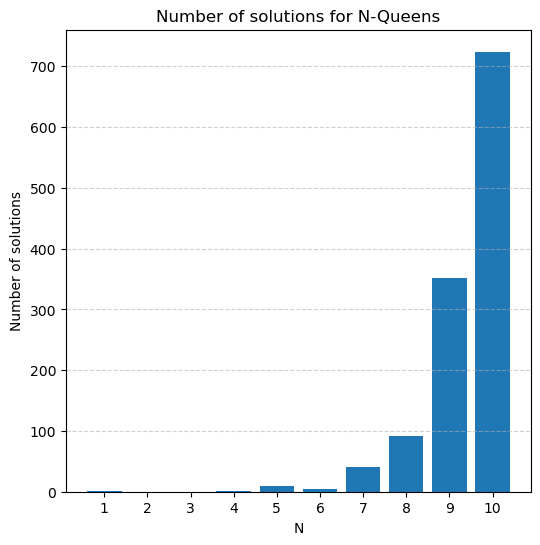

In [112]:
import matplotlib.pyplot as plt

data = []
for i in range(1,11):
    data.append(N_Queens_count(i))


N_values = range(1, 1 + len(data))

plt.figure(figsize=(6, 6))

plt.bar(N_values, data)
plt.xlabel("N")
plt.ylabel("Number of solutions")
plt.title("Number of solutions for N-Queens")

plt.xticks(N_values)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Phương pháp heuristic

Xây dựng một phương án heuristic dựa trên số cặp tấn công lẫn nhau của các quân hậu trên bàn cờ

Hoạt động nhanh hơn so với backtracking và chỉ cho ra một nghiệm với các bước hoàn toàn ngẫu nhiên

#### Về ý tưởng:
- Mỗi hàng đặt đúng 1 quân hậu
- Biểu diễn nghiệm bằng mảng `pos`, trong đó:
  - `pos[i]` là cột đặt quân hậu ở hàng `i`
- Lặp:
  - Chọn ngẫu nhiên một hàng đang có xung đột
  - Đưa quân hậu sang cột có số xung đột nhỏ nhất
- Dừng khi không còn xung đột (khi h = 0)

#### Giải thuật:
```
Min-Conflicts-N-Queens(N):
    pos ← random configuration
    maxSteps ← 100 × N (Bước chống lặp vô hạn)
    for step = 1 → maxSteps:
        if h(pos) = 0:
            return pos
        row ← randomly select a conflicted row
        col ← column with minimum conflicts in row
        pos[row] ← col
    return failure

```

#### Cài đặt:

In [113]:
import random as rd

def conflicts_counter(row, col, pos): # Chức năng để đếm số hậu tấn công tại ô row, col
    N = len(pos)
    cnt = 0
    for i in range(0,N):
        if i == row: continue
        if abs(row - i) == abs(pos[i] - col) or pos[i] == col: # trùng chéo và trùng dọc
            cnt+=1
    return cnt
    
def cnt_conflicts_pairs(pos): # đếm số cặp đang tấn công nhau -> h(pos)
    h = 0
    N = len(pos)
    for i in range(N):
        for j in range(i+1, N):
            if pos[i] == pos[j] or abs(i-j) == abs(pos[i]-pos[j]):
                h+=1
    return h

def select_row(pos):   # phụ trợ cho việc chọn dòng ngẫu nhiên có sự xung đột lớn hơn 0
    collect = [row for row in range(len(pos)) if conflicts_counter(row, pos[row], pos) > 0]
    if not collect: return None
    return rd.choice(collect)

In [117]:
def N_Queens_H(N, verbose = True):
    step_count = 0
    ## Giả sử đặt N quân hậu tất cả ở cột đầu tiên

    pos = [0]*N
    #pos = [rd.randint(0, N-1) for _ in range(N)] ## đặt hậu nẫu nhiên trên từng dòng

    maxStep = 100*N

    for step in range(1, maxStep):
        step_count+=1
        h = cnt_conflicts_pairs(pos)# heuristic
        if verbose: print(f'\nStep {step}, conflict h = {h}')
        parseBoard(pos, verbose)
        if h == 0:
            if verbose: print(f'Found sulution!')
            return pos, step_count
        row = select_row(pos)
        if row is None: return None
        min_conf = 10**9
        best_col = []
        for col in range(0,N):
            conf = conflicts_counter(row, col, pos)     
            if conf < min_conf:                         # nếu ô hiện tại có số xung đột nhỏ hơn
                min_conf = conf                         # di chuyển đến ô đó
                best_col = [col]                        # cập nhật cột
            elif conf == min_conf:              
                best_col.append(col)                    

        pos[row] = rd.choice(best_col)                  # chọn ngẫu nhiên những ô có xung đột bằng nhau trên cùng hàng
    return None

In [137]:
pos, step = N_Queens_H(4)
print(f'{step} bước')


Step 1, conflict h = 6
Q . . . 
Q . . . 
Q . . . 
Q . . . 

Step 2, conflict h = 4
. . Q . 
Q . . . 
Q . . . 
Q . . . 

Step 3, conflict h = 1
. . Q . 
Q . . . 
. . . Q 
Q . . . 

Step 4, conflict h = 0
. . Q . 
Q . . . 
. . . Q 
. Q . . 
Found sulution!
4 bước


#### Mối quan hệ giữa kích thước bàn cờ và số bước heuristic xấp xỉ

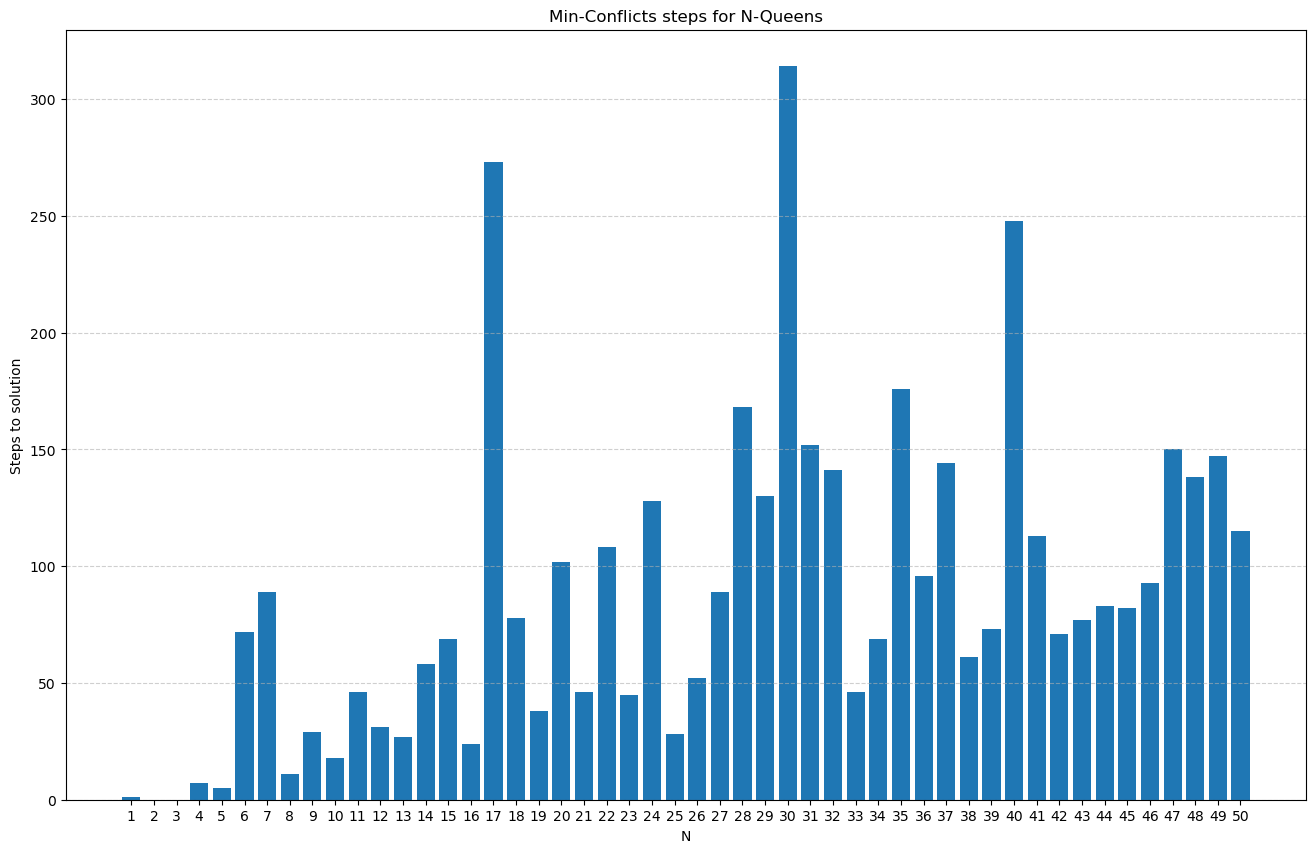

In [138]:
data = []

for i in range(1, 51):
    res = N_Queens_H(i, verbose=False)
    if res is None:
        data.append(0)          # hoặc 100*i nếu muốn thể hiện fail
    else:
        _, step2 = res
        data.append(step2)

N_values = range(1, 1 + len(data))

plt.figure(figsize=(16, 10))
plt.bar(N_values, data)
plt.xlabel("N")
plt.ylabel("Steps to solution")
plt.title("Min-Conflicts steps for N-Queens")

plt.xticks(N_values)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


*Kết quả cho ra mang tính ngẫu nhiên*

# Kết thúc